Ноутбук: Анализ retrieval-методов (BM25, Dense, Hybrid, SPLADE, Triple Hybrid)
1. Введение
В этом ноутбуке мы сравниваем пять методов поиска:

BM25 – лексический baseline со стеммингом (Porter)

Dense – семантический поиск (e5-small-v2)

Hybrid BM25+Dense – объединение ранжирований через RRF

SPLADE – разреженный нейросетевой поиск

Triple Hybrid – RRF всех трёх методов

Оценка производится на уровне документов: каждый чанк маппится на документ, дубликаты документов в выдаче удаляются (учитывается только первое появление).
Метрики: Recall@k, NDCG@k, MRR@k для k ∈ {1, 5, 10, 100, 1000}.
Дополнительно проводятся парные статистические тесты (Wilcoxon signed-rank с поправкой Холма) и бутстраповские доверительные интервалы.



In [51]:
import os
import pickle
import warnings
from collections import defaultdict
from itertools import combinations

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

# Конфигурация (пути к файлам)
CHUNKS_PARQUET = "chunks_fixed_v1.parquet"
QUESTIONS_PARQUET = "questions_for_sample.parquet"
BM25_RESULTS_PKL = "retrieval_results/bm25_stemming_chunks_top1000.pkl"
DENSE_RESULTS_PKL = "retrieval_results/dense_chunks_top1000.pkl"
SPLADE_RESULTS_PKL = "splade_results_from_index(1).pkl"

K_VALUES = [1, 5, 10, 100, 1000]
RRF_K = 60
RANDOM_SEED = 42
ALPHA = 0.05
np.random.seed(RANDOM_SEED)

# Папка для сохранения графиков
OUT_DIR = "retrieval_analysis_plots"
os.makedirs(OUT_DIR, exist_ok=True)

print("Настройки загружены.")

Настройки загружены.


## Даннык

In [52]:
def load_ground_truth():
    df_chunks = pd.read_parquet(CHUNKS_PARQUET)
    df_questions = pd.read_parquet(QUESTIONS_PARQUET)
    chunk_to_doc = dict(zip(df_chunks["chunk_id"], df_chunks["doc_id"]))
    expected_doc_ids_by_qid = {
        row["question_id"]: set(row["expected_doc_ids"])
        for _, row in df_questions.iterrows()
    }
    qids_order = list(df_questions["question_id"])
    return chunk_to_doc, expected_doc_ids_by_qid, qids_order

chunk_to_doc, expected_doc_ids_by_qid, qids_order = load_ground_truth()
print(f"Загружено {len(chunk_to_doc)} чанков, {len(expected_doc_ids_by_qid)} запросов.")

Загружено 570005 чанков, 138 запросов.


In [53]:
def load_pkl(path):
    with open(path, "rb") as f:
        return pickle.load(f)

bm25_results = load_pkl(BM25_RESULTS_PKL)
dense_results = load_pkl(DENSE_RESULTS_PKL)
splade_results = load_pkl(SPLADE_RESULTS_PKL)

print(f"BM25: {len(bm25_results)} запросов")
print(f"Dense: {len(dense_results)} запросов")
print(f"SPLADE: {len(splade_results)} запросов")

BM25: 138 запросов
Dense: 138 запросов
SPLADE: 138 запросов


In [54]:
def reciprocal_rank_fusion(rankings, k=RRF_K):
    scores = defaultdict(float)
    for ranking in rankings:
        for rank, chunk_id in enumerate(ranking):
            scores[chunk_id] += 1.0 / (k + rank + 1)
    return [cid for cid, _ in sorted(scores.items(), key=lambda x: x[1], reverse=True)]

def build_hybrid_results(bm25_results, dense_results, splade_results, top_k=1000):
    hybrid_bd = {}
    triple = {}
    for qid in bm25_results:
        if qid not in dense_results:
            continue
        hybrid_bd[qid] = reciprocal_rank_fusion(
            [bm25_results[qid], dense_results[qid]], k=RRF_K
        )[:top_k]
        if qid in splade_results:
            triple[qid] = reciprocal_rank_fusion(
                [bm25_results[qid], dense_results[qid], splade_results[qid]], k=RRF_K
            )[:top_k]
    return hybrid_bd, triple

hybrid_bd, triple = build_hybrid_results(bm25_results, dense_results, splade_results)
print(f"Hybrid BM25+Dense: {len(hybrid_bd)} запросов")
print(f"Triple Hybrid: {len(triple)} запросов")

Hybrid BM25+Dense: 138 запросов
Triple Hybrid: 138 запросов


In [55]:
def compute_metrics_doc_level_per_query(retrieved_lists, chunk_to_doc, expected_doc_ids, k_values=K_VALUES):
    per_k = {k: {} for k in k_values}
    for qid, expected_docs in expected_doc_ids.items():
        if qid not in retrieved_lists or not expected_docs:
            continue
        full_retrieved = retrieved_lists[qid]
        for k in k_values:
            retrieved_chunks = full_retrieved[:k]
            seen_docs, seen_set = [], set()
            for chunk_id in retrieved_chunks:
                doc_id = chunk_to_doc.get(chunk_id)
                if doc_id is not None and doc_id not in seen_set:
                    seen_set.add(doc_id)
                    seen_docs.append(doc_id)
            n_expected = len(expected_docs)
            n_found = len(seen_set & expected_docs)
            recall = n_found / n_expected
            dcg = sum((1.0 if doc_id in expected_docs else 0.0) / np.log2(i + 2)
                      for i, doc_id in enumerate(seen_docs))
            ideal_rels = [1.0] * min(n_expected, k)
            idcg = sum(rel / np.log2(i + 2) for i, rel in enumerate(ideal_rels))
            ndcg = dcg / idcg if idcg > 0 else 0.0
            rr = 0.0
            for i, doc_id in enumerate(seen_docs):
                if doc_id in expected_docs:
                    rr = 1.0 / (i + 1)
                    break
            per_k[k][qid] = {"Recall": recall, "NDCG": ndcg, "MRR": rr}
    return {k: pd.DataFrame.from_dict(v, orient="index") for k, v in per_k.items()}

# Собираем все методы в один словарь
methods_results = {
    "BM25": bm25_results,
    "Dense": dense_results,
    "Hybrid BM25+Dense": hybrid_bd,
    "SPLADE": splade_results,
    "Triple Hybrid": triple,
}

per_query_by_method = {}
for name, results in methods_results.items():
    per_query_by_method[name] = compute_metrics_doc_level_per_query(
        results, chunk_to_doc, expected_doc_ids_by_qid, K_VALUES
    )
    print(f"{name}: вычислено для {len(per_query_by_method[name][1])} запросов")

BM25: вычислено для 138 запросов
Dense: вычислено для 138 запросов
Hybrid BM25+Dense: вычислено для 138 запросов
SPLADE: вычислено для 138 запросов
Triple Hybrid: вычислено для 138 запросов


In [56]:
def aggregate_table(per_query_by_method):
    rows = []
    for method, per_k in per_query_by_method.items():
        for k, df in per_k.items():
            rows.append({
                "Method": method, "k": k,
                "Recall@k": df["Recall"].mean(),
                "NDCG@k": df["NDCG"].mean(),
                "MRR@k": df["MRR"].mean(),
                "n_queries": len(df),
            })
    return pd.DataFrame(rows)

comparison_df = aggregate_table(per_query_by_method)
print("Сводная таблица средних метрик:")
display(comparison_df.round(4))

# Pivot для удобства
for metric in ["Recall@k", "NDCG@k", "MRR@k"]:
    print(f"\n{metric}")
    display(comparison_df.pivot(index="Method", columns="k", values=metric).round(4))

Сводная таблица средних метрик:


,Method,k,Recall@k,NDCG@k,MRR@k,n_queries
0,BM25,1,0.3875,0.5000,0.5000,138
1,BM25,5,0.5338,0.5054,0.5886,138
2,BM25,10,0.5689,0.5127,0.5948,138
3,BM25,100,0.6746,0.5371,0.6008,138
4,BM25,1000,0.7208,0.5440,0.6012,138
5,Dense,1,0.2414,0.3188,0.3188,138
6,Dense,5,0.3977,0.3554,0.4115,138
7,Dense,10,0.4501,0.3706,0.4196,138
8,Dense,100,0.5526,0.3942,0.4251,138
9,Dense,1000,0.6674,0.4094,0.4257,138



Recall@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.3875,0.5338,0.5689,0.6746,0.7208
Dense,0.2414,0.3977,0.4501,0.5526,0.6674
Hybrid BM25+Dense,0.4042,0.5141,0.5653,0.6674,0.7198
SPLADE,0.3788,0.5085,0.5673,0.6474,0.7099
Triple Hybrid,0.3984,0.5627,0.5987,0.6766,0.7290



NDCG@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5054,0.5127,0.5371,0.5440
Dense,0.3188,0.3554,0.3706,0.3942,0.4094
Hybrid BM25+Dense,0.5290,0.5009,0.5151,0.5398,0.5476
SPLADE,0.4710,0.4794,0.4965,0.5169,0.5255
Triple Hybrid,0.5290,0.5243,0.5340,0.5550,0.5628



MRR@k


k,1,5,10,100,1000
Method,,,,,
BM25,0.5000,0.5886,0.5948,0.6008,0.6012
Dense,0.3188,0.4115,0.4196,0.4251,0.4257
Hybrid BM25+Dense,0.5290,0.5944,0.6045,0.6111,0.6115
SPLADE,0.4710,0.5478,0.5569,0.5616,0.5621
Triple Hybrid,0.5290,0.6098,0.6155,0.6224,0.6229


In [61]:
import pandas as pd
import numpy as np
from scipy import stats
from itertools import combinations

ALPHA = 0.05

# ---- Глобальный тест Фридмана ----
def friedman_test(per_query_by_method, k, metric):
    """
    Выполняет тест Фридмана для сравнения всех методов по одной метрике и k.
    Возвращает p-value.
    """
    methods = list(per_query_by_method.keys())
    # Собираем значения для каждого метода в виде списка массивов
    data = [per_query_by_method[m][k][metric].values for m in methods]
    # Убедимся, что все массивы одинаковой длины (общие запросы)
    min_len = min(len(d) for d in data)
    data_cut = [d[:min_len] for d in data]  # обрезаем до минимальной длины, чтобы сохранить парность
    stat, p_value = stats.friedmanchisquare(*data_cut)
    return p_value

# ---- Попарные тесты Уилкоксона с поправкой Бонферрони ----
def pairwise_wilcoxon_bonferroni(per_query_by_method, k, metric, alpha=ALPHA):
    """
    Выполняет попарные тесты Уилкоксона для всех пар методов и применяет
    поправку Бонферрони. Возвращает DataFrame с результатами.
    """
    methods = list(per_query_by_method.keys())
    pairs = list(combinations(methods, 2))
    n_pairs = len(pairs)
    bonferroni_alpha = alpha / n_pairs if n_pairs > 0 else alpha

    records = []
    for m1, m2 in pairs:
        arr1 = per_query_by_method[m1][k][metric].values
        arr2 = per_query_by_method[m2][k][metric].values
        # Общие индексы (запросы, для которых есть данные у обоих методов)
        common_idx = per_query_by_method[m1][k].index.intersection(per_query_by_method[m2][k].index)
        if len(common_idx) < 10:
            continue
        a = per_query_by_method[m1][k].loc[common_idx, metric].values
        b = per_query_by_method[m2][k].loc[common_idx, metric].values

        # Тест Уилкоксона (парный)
        try:
            w_stat, p_raw = stats.wilcoxon(a, b, zero_method="wilcox")
        except ValueError:
            w_stat, p_raw = np.nan, 1.0

        # Скорректированное p-value (Бонферрони)
        p_corrected = min(p_raw * n_pairs, 1.0)
        significant = p_corrected < alpha

        records.append({
            'method_A': m1,
            'method_B': m2,
            'n_queries': len(common_idx),
            'mean_A': a.mean(),
            'mean_B': b.mean(),
            'diff_A_minus_B': a.mean() - b.mean(),
            'p_raw': p_raw,
            'p_bonferroni': p_corrected,
            'significant': significant
        })

    return pd.DataFrame(records)

# ---- Основной блок выполнения ----
all_results = {}
global_pvalues = {}

for metric in ["Recall", "NDCG", "MRR"]:
    for k in K_VALUES:
        # Глобальный тест
        p_global = friedman_test(per_query_by_method, k, metric)
        global_pvalues[(metric, k)] = p_global

        if p_global < ALPHA:
            # Если глобальные различия значимы, выполняем попарные сравнения
            df_pair = pairwise_wilcoxon_bonferroni(per_query_by_method, k, metric)
            all_results[(metric, k)] = df_pair
        else:
            all_results[(metric, k)] = None  # или пустой DataFrame

# ---- Вывод глобальных p-значений ----
print("Глобальные тесты Фридмана (p-values):")
global_df = pd.DataFrame(
    [(metric, k, p) for (metric, k), p in global_pvalues.items()],
    columns=['Metric', 'k', 'p_global']
)
display(global_df.round(4))

# ---- Вывод значимых попарных сравнений (например, для NDCG@10) ----
metric_show = "NDCG"
k_show = 10
df_show = all_results.get((metric_show, k_show))
if df_show is not None and not df_show.empty:
    print(f"\nПопарные сравнения для {metric_show}@{k_show} (скорректировано Бонферрони):")
    display(df_show[['method_A', 'method_B', 'p_bonferroni', 'significant']].round(4))
else:
    print(f"\nДля {metric_show}@{k_show} глобальный тест не значим (p ≥ {ALPHA}), попарные сравнения не проводились.")

Глобальные тесты Фридмана (p-values):


,Metric,k,p_global
0,Recall,1,0.0
1,Recall,5,0.0
2,Recall,10,0.0
3,Recall,100,0.0
4,Recall,1000,0.0
5,NDCG,1,0.0
6,NDCG,5,0.0
7,NDCG,10,0.0
8,NDCG,100,0.0
9,NDCG,1000,0.0



Попарные сравнения для NDCG@10 (скорректировано Бонферрони):


,method_A,method_B,p_bonferroni,significant
0,BM25,Dense,0.0000,True
1,BM25,Hybrid BM25+Dense,1.0000,False
2,BM25,SPLADE,1.0000,False
3,BM25,Triple Hybrid,1.0000,False
4,Dense,Hybrid BM25+Dense,0.0000,True
5,Dense,SPLADE,0.0001,True
6,Dense,Triple Hybrid,0.0000,True
7,Hybrid BM25+Dense,SPLADE,1.0000,False
8,Hybrid BM25+Dense,Triple Hybrid,0.8859,False
9,SPLADE,Triple Hybrid,0.3531,False


In [62]:
sig = tests_df[(tests_df["k"] == 10) & (tests_df["significant_holm_0.05"])]
if not sig.empty:
    display(sig[["metric", "method_A", "method_B", "diff_A_minus_B", "p_wilcoxon_holm"]].round(4))
else:
    print("Значимых различий при k=10 не обнаружено.")

,metric,method_A,method_B,diff_A_minus_B,p_wilcoxon_holm
60,Recall,BM25,Dense,0.1188,0.0022
61,NDCG,BM25,Dense,0.1420,0.0000
62,MRR,BM25,Dense,0.1752,0.0000
72,Recall,Dense,Hybrid BM25+Dense,-0.1152,0.0003
73,NDCG,Dense,Hybrid BM25+Dense,-0.1444,0.0000
74,MRR,Dense,Hybrid BM25+Dense,-0.1849,0.0000
75,Recall,Dense,SPLADE,-0.1171,0.0074
76,NDCG,Dense,SPLADE,-0.1258,0.0001
77,MRR,Dense,SPLADE,-0.1373,0.0004
78,Recall,Dense,Triple Hybrid,-0.1486,0.0000


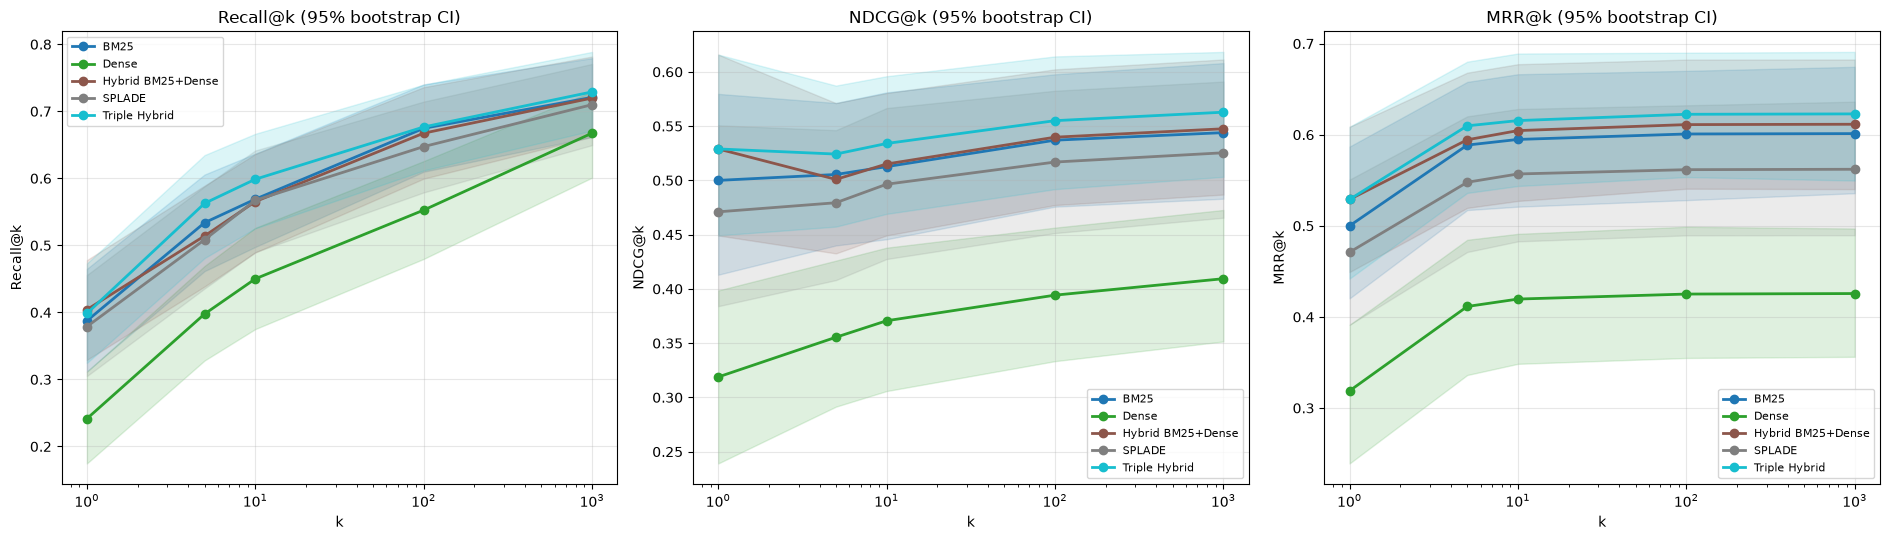

График сохранён: retrieval_analysis_plots/metrics_vs_k.png


In [59]:
def plot_metrics_with_ci(per_query_by_method, k_values=K_VALUES, out_path=f"{OUT_DIR}/metrics_vs_k.png"):
    methods = list(per_query_by_method.keys())
    colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

    for ax, metric in zip(axes, ["Recall", "NDCG", "MRR"]):
        for method, color in zip(methods, colors):
            means, ci_los, ci_his = [], [], []
            for k in k_values:
                vals = per_query_by_method[method][k][metric].to_numpy()
                boot_idx = np.random.randint(0, len(vals), size=(2000, len(vals)))
                boot_means = vals[boot_idx].mean(axis=1)
                lo, hi = np.percentile(boot_means, [2.5, 97.5])
                means.append(vals.mean())
                ci_los.append(lo)
                ci_his.append(hi)
            ax.plot(k_values, means, marker="o", label=method, color=color, linewidth=2)
            ax.fill_between(k_values, ci_los, ci_his, color=color, alpha=0.15)

        ax.set_xlabel("k")
        ax.set_ylabel(f"{metric}@k")
        ax.set_title(f"{metric}@k (95% bootstrap CI)")
        ax.set_xscale("log")
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_metrics_with_ci(per_query_by_method)

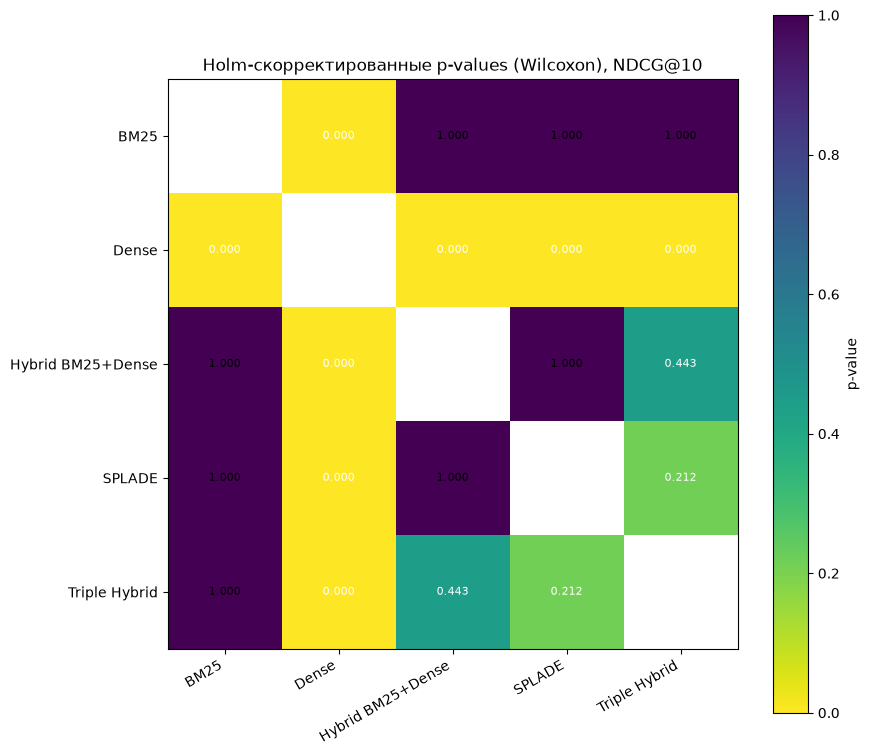

График сохранён: retrieval_analysis_plots/pvalue_heatmap_NDCG_at_k10.png


In [60]:
def plot_pvalue_heatmap(tests_df, k=10, metric="NDCG", out_path=None):
    if out_path is None:
        out_path = f"{OUT_DIR}/pvalue_heatmap_{metric}_at_k{k}.png"

    sub = tests_df[(tests_df["k"] == k) & (tests_df["metric"] == metric)]
    methods = sorted(set(sub["method_A"]) | set(sub["method_B"]))
    mat = pd.DataFrame(np.ones((len(methods), len(methods))), index=methods, columns=methods)
    for _, row in sub.iterrows():
        mat.loc[row["method_A"], row["method_B"]] = row["p_wilcoxon_holm"]
        mat.loc[row["method_B"], row["method_A"]] = row["p_wilcoxon_holm"]
    
    # Исправление: устанавливаем диагональ через iloc
    for i in range(len(methods)):
        mat.iloc[i, i] = np.nan

    fig, ax = plt.subplots(figsize=(1.4 * len(methods) + 2, 1.4 * len(methods) + 1))
    # mat.values может быть read-only, но мы используем mat.to_numpy() для imshow (это копия)
    im = ax.imshow(mat.to_numpy(dtype=float), cmap="viridis_r", vmin=0, vmax=1)
    ax.set_xticks(range(len(methods)))
    ax.set_yticks(range(len(methods)))
    ax.set_xticklabels(methods, rotation=30, ha="right")
    ax.set_yticklabels(methods)
    for i in range(len(methods)):
        for j in range(len(methods)):
            val = mat.iloc[i, j]
            if not np.isnan(val):
                ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                        color="white" if val < 0.5 else "black", fontsize=8)
    ax.set_title(f"Holm-скорректированные p-values (Wilcoxon), {metric}@{k}")
    fig.colorbar(im, label="p-value")
    plt.tight_layout()
    plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"График сохранён: {out_path}")

plot_pvalue_heatmap(tests_df, k=10, metric="NDCG")